In [3]:
import numpy 
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
name = "df_rows_0_0_08012026_233302_ncells_6000_A_to_B_rep_0_a300dfa6"
df_twin = pd.read_csv(f'/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition///A_to_B//{name}.csv')
parent_df = pd.read_csv(f"/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/binomial_partition/A_to_B/simulation_before_division_{name}.csv")

In [52]:
df = df_twin[df_twin['time_step'] == 0]
df_parent = parent_df[parent_df['time_step'] == 1499]

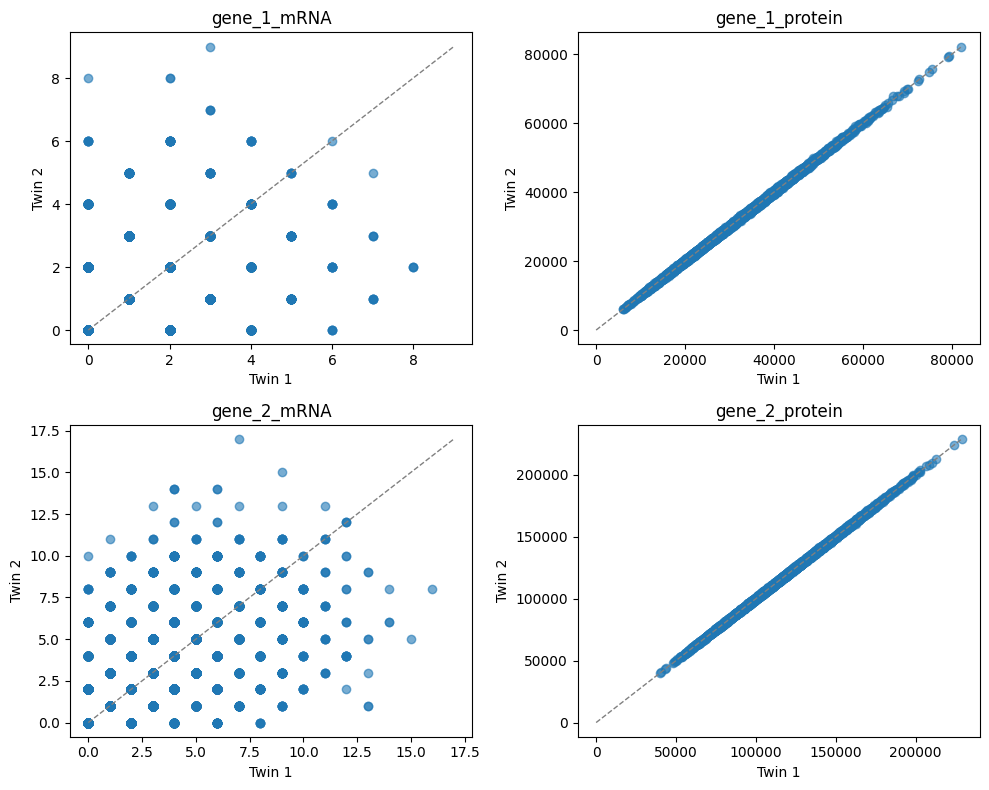

In [54]:
import matplotlib.pyplot as plt

# ---- split daughters ----
df_rep1 = df[df["replicate"] == 1].sort_values("clone_id")
df_rep2 = df[df["replicate"] == 2].sort_values("clone_id")

# ---- align parents using cell_id == clone_id ----
df_parent_aligned = (
    df_parent
    .set_index("cell_id")
    .loc[df_rep1["clone_id"]]
    .reset_index()
)

# sanity checks
assert (df_rep1["clone_id"].values == df_rep2["clone_id"].values).all()
assert (df_rep1["clone_id"].values == df_parent_aligned["cell_id"].values).all()

# ---- genes to plot ----
genes = [
    "gene_1_mRNA",
    "gene_1_protein",
    "gene_2_mRNA",
    "gene_2_protein",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, gene in zip(axes, genes):
    parent = df_parent_aligned[gene]
    twin1  = df_rep1[gene]
    twin2  = df_rep2[gene]

    ax.scatter(twin1, twin2, alpha=0.6, label="Twin 1")

    lim = max(parent.max(), twin1.max(), twin2.max())
    ax.plot([0, lim], [0, lim], "--", color="grey", lw=1)

    ax.set_xlabel("Twin 1")
    ax.set_ylabel("Twin 2")
    ax.set_title(gene)
    # ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [50]:
for gene in genes:
    print(
        gene,
        df_parent_aligned[gene].mean(),
        df_rep1[gene].mean(),
        df_rep2[gene].mean(),
    )


gene_1_mRNA 0.8263333333333334 0.8266666666666667 0.826
gene_1_protein 29955.1315 29957.029666666665 29953.233333333334
gene_2_mRNA 3.3051666666666666 3.308 3.3023333333333333
gene_2_protein 119550.68333333333 119547.62316666667 119553.7435
